# 1. Selección del problema

Para este proyecto se seleccionó el problema **Orszag–Tang Vortex**, este hace parte de Test_Problems, subsección MHD de PLUTO. Este problema constituye uno de los casos de prueba más utilizados en magnetohidrodinámica computacional (MHD) y es considerado un benchmark clásico para la validación de esquemas numéricos destinados a resolver las ecuaciones de MHD ideal.

El problema fue introducido originalmente por Orszag y Tang (1979) con el objetivo de estudiar la evolución no lineal producida por la interacción entre campos de velocidad y campos magnéticos periódicos en dos dimensiones. A medida que el sistema evoluciona, la interacción entre diferentes modos magnetosónicos genera una compleja red de ondas de choque, regiones de compresión y rarefacción, láminas de corriente y estructuras turbulentas que permiten evaluar simultáneamente la precisión, estabilidad y capacidad de captura de discontinuidades de un método numérico.

La elección de este problema se realizó por varias razones. En primer lugar, satisface el requisito establecido en el proyecto de trabajar con un problema magnetohidrodinámico de al menos dos dimensiones. En segundo lugar, representa uno de los casos de prueba más importantes dentro de la literatura especializada, siendo ampliamente utilizado para comparar distintos códigos de simulación MHD. Finalmente, su riqueza física permite analizar una gran variedad de fenómenos relevantes, incluyendo la propagación de ondas magnetosónicas, la formación de choques y la evolución de estructuras complejas inducidas por la interacción entre el fluido y el campo magnético.

El dominio computacional consiste en una región cuadrada periódica definida por

$$(x,y)\in[0,1]\times[0,1]$$

donde se imponen condiciones de frontera periódicas en ambas direcciones espaciales. A partir de condiciones iniciales cuidadosamente diseñadas para excitar múltiples modos de propagación, el sistema evoluciona rápidamente hacia un régimen altamente no lineal que constituye una prueba exigente para cualquier esquema numérico.

El objetivo principal de este trabajo consiste en reproducir la evolución del vórtice de Orszag–Tang mediante dos enfoques independientes. El primero corresponde a la simulación realizada con el código PLUTO utilizando la configuración de referencia suministrada por el propio paquete. El segundo consiste en la implementación de un solucionador magnetohidrodinámico desarrollado en Python empleando los métodos numéricos estudiados durante el curso. Posteriormente, ambos resultados serán comparados con el fin de evaluar la capacidad del código desarrollado para reproducir la física esencial del problema y analizar las diferencias producidas por los distintos métodos numéricos utilizados.


# 2. Marco Teórico

## 2.1 Magnetohidrodinámica ideal

La magnetohidrodinámica (MHD) es la teoría que describe el comportamiento de un fluido conductor en presencia de campos magnéticos. Constituye una combinación de la mecánica de fluidos y el electromagnetismo clásico, permitiendo modelar sistemas astrofísicos como atmósferas estelares, discos de acreción, vientos estelares, medios interestelares y plasmas magnetizados en general.

La formulación utilizada en este trabajo corresponde a la aproximación de **MHD ideal**, la cual supone que el plasma posee conductividad eléctrica infinita. Bajo esta hipótesis no existe disipación resistiva y las líneas de campo magnético permanecen congeladas dentro del fluido, fenómeno conocido como *flux freezing*.

Las ecuaciones de MHD ideal pueden obtenerse combinando las ecuaciones de Euler para fluidos compresibles con las ecuaciones de Maxwell en el límite no relativista.

## 2.2 Conservación de masa

La primera ecuación fundamental corresponde a la ecuación de continuidad,

$$\frac{\partial \rho}{\partial t} +\nabla\cdot(\rho \mathbf{v})=0$$

Aquí:

* $\rho$ representa la densidad de masa del fluido.
* $\mathbf{v}$ es el campo de velocidad.
* $\rho\mathbf{v}$ corresponde al flujo de masa.

Esta ecuación expresa que la masa no puede crearse ni destruirse dentro del dominio. Cualquier variación local de densidad debe estar asociada al transporte de materia hacia o desde una región determinada.

## 2.3 Conservación de momento

La dinámica del fluido está gobernada por

$$\frac{\partial (\rho \mathbf{v})}{\partial t} +\nabla\cdot \left[ \rho\mathbf{v}\mathbf{v} + \left(P+\frac{B^2}{2}\right)\mathbf{I}- \mathbf{B}\mathbf{B}\right] = 0$$

donde:

* $P$ es la presión térmica.
* $\mathbf{B}$ es el campo magnético.
* $B^2=\mathbf{B}\cdot\mathbf{B}$.
* $\mathbf{I}$ es el tensor identidad.

El término

$$\rho\mathbf{v}\mathbf{v}$$

representa el transporte advectivo de momento.

El término

$$P\mathbf{I}$$

corresponde a la presión hidrodinámica ordinaria.

Por su parte,

$$\frac{B^2}{2}$$

actúa como una presión magnética isotrópica asociada a la energía almacenada en el campo magnético.

Finalmente,

$$-\mathbf{B}\mathbf{B}$$

describe la tensión magnética. Este término surge debido a que las líneas de campo se comportan como bandas elásticas capaces de transmitir fuerzas a lo largo de su dirección.

La combinación entre presión magnética y tensión magnética es responsable de gran parte de la dinámica característica de los plasmas magnetizados.


## 2.4 Conservación de energía

La evolución de la energía total está dada por

$$ \frac{\partial E}{\partial t} + \nabla\cdot \left[ \left(E+P+\frac{B^2}{2} \right)\mathbf{v}- (\mathbf{v}\cdot\mathbf{B})\mathbf{B}\right] = 0 $$

La energía total por unidad de volumen se define como

$$E = \frac{P}{\gamma-1} + \frac{1}{2}\rho v^2 + \frac{1}{2}B^2$$

Los tres términos representan:

$$\frac{P}{\gamma-1}$$

energía interna del gas,

$$\frac{1}{2}\rho v^2$$

energía cinética del fluido,

y

$$\frac{1}{2}B^2$$

energía magnética.

En este trabajo se utiliza

$$\gamma=\frac{5}{3} $$

correspondiente a un gas ideal monoatómico.

## 2.5 Ecuación de inducción magnética

La evolución temporal del campo magnético se describe mediante

$$\frac{\partial \mathbf{B}}{\partial t} + \nabla\times (\mathbf{v}\times\mathbf{B})=0$$

Esta ecuación expresa el principio de congelamiento del flujo magnético. Las líneas de campo son transportadas por el movimiento del plasma y pueden estirarse, comprimirse y deformarse a medida que el fluido evoluciona.
La interacción entre esta ecuación y la ecuación de momento es la responsable de la aparición de ondas de Alfvén y ondas magnetosónicas.

## 2.6 Restricción de divergencia nula

Una condición fundamental de la teoría es

$$\nabla\cdot\mathbf{B}=0.$$

Esta ecuación expresa la inexistencia de monopolos magnéticos y establece que las líneas de campo magnético deben formar curvas cerradas o extenderse indefinidamente sin poseer fuentes ni sumideros. Desde el punto de vista numérico, preservar esta condición constituye uno de los principales desafíos de los códigos MHD modernos.


## 2.7 El problema de Orszag–Tang

El vórtice de Orszag–Tang fue diseñado como un experimento numérico para estudiar la transición desde una configuración inicialmente suave hacia un régimen altamente no lineal dominado por choques e interacciones magnetohidrodinámicas complejas.

Las condiciones iniciales empleadas son

$$\rho=\frac{25}{9}$$

$$P=\frac{5}{3}$$

$$v_x=-\sin(y)$$

$$v_y=\sin(x)$$

$$B_x=-\sin(y)$$

$$B_y=\sin(2x).$$

Estas configuraciones periódicas excitan simultáneamente múltiples modos de propagación. A medida que transcurre el tiempo, la interacción entre las ondas genera regiones de compresión, rarefacción, láminas de corriente y estructuras turbulentas que constituyen una prueba particularmente exigente para cualquier método numérico.

Por esta razón, el problema de Orszag–Tang se ha convertido en uno de los benchmarks más utilizados para validar códigos de magnetohidrodinámica computacional.

## 2.8 Estado del arte

El vórtice de Orszag–Tang constituye uno de los problemas de referencia más utilizados en magnetohidrodinámica computacional desde su introducción por Orszag y Tang en 1979. Su popularidad se debe a que, a partir de condiciones iniciales relativamente simples, el sistema desarrolla rápidamente una gran variedad de fenómenos físicos relevantes, incluyendo ondas magnetosónicas, choques, láminas de corriente, reconexión magnética y estructuras turbulentas. Como resultado, se ha convertido en una prueba estándar para validar nuevos algoritmos numéricos y comparar distintos códigos de simulación.

Durante las últimas décadas, el problema ha sido utilizado extensivamente para evaluar métodos de captura de choques, esquemas de reconstrucción de alto orden y técnicas de control de la divergencia magnética. Códigos ampliamente utilizados en astrofísica computacional, como PLUTO, ATHENA, ATHENA++, FLASH y MPI-AMRVAC, incluyen variantes del problema de Orszag–Tang dentro de sus conjuntos de pruebas estándar debido a su capacidad para poner a prueba simultáneamente la precisión, estabilidad y robustez de los algoritmos implementados.

Uno de los principales desafíos numéricos en simulaciones MHD consiste en preservar la condición

$$\nabla\cdot\mathbf{B}=0,$$

ya que pequeñas violaciones de esta restricción pueden generar fuerzas magnéticas no físicas y afectar significativamente la evolución de la solución. Por esta razón, gran parte del desarrollo reciente en magnetohidrodinámica computacional se ha concentrado en la construcción de métodos capaces de mantener dicha condición con alta precisión. Entre las estrategias más utilizadas se encuentran los métodos de *Constrained Transport (CT)*, la limpieza hiperbólica de divergencia (*hyperbolic divergence cleaning*) y diversos esquemas de corrección proyectiva.

Otro aspecto de gran interés ha sido el desarrollo de solucionadores de Riemann cada vez más sofisticados. Mientras los esquemas más simples, como Lax–Friedrichs o HLL, ofrecen gran robustez numérica, los solucionadores modernos como HLLC y HLLD permiten resolver un mayor número de modos físicos presentes en las ecuaciones MHD, reduciendo significativamente la difusión numérica y mejorando la resolución de estructuras de pequeña escala.

En paralelo, los avances en reconstrucción espacial han permitido incrementar notablemente la precisión de las simulaciones. Métodos de segundo orden, como MUSCL y las reconstrucciones parabólicas, han sido complementados por esquemas de orden superior como PPM, WENO y MP5, los cuales logran capturar con mayor detalle las estructuras turbulentas y los gradientes pronunciados presentes en flujos magnetizados.

Dentro de este contexto, el código PLUTO representa uno de los entornos de simulación más utilizados en astrofísica moderna. Su arquitectura modular permite combinar distintos solucionadores de Riemann, esquemas temporales y técnicas de reconstrucción espacial, convirtiéndolo en una herramienta de referencia para el estudio de plasmas astrofísicos. En este trabajo, los resultados obtenidos con PLUTO sirven como solución de referencia para evaluar el desempeño del solucionador desarrollado en Python.

Aunque la implementación realizada en Python es considerablemente más sencilla que los códigos profesionales actuales, incorpora los elementos fundamentales estudiados durante el curso, incluyendo integración temporal mediante Runge–Kutta de segundo orden, reconstrucción espacial parabólica y un solucionador aproximado de Riemann tipo HLL. Esto permite reproducir adecuadamente la física dominante del problema y proporciona una base sólida para comprender los principios numéricos que sustentan los códigos MHD modernos.



# 3. Simulación utilizando PLUTO

## 3.1 Configuración numérica

La primera etapa del proyecto consistió en reproducir el problema de Orszag–Tang utilizando el código magnetohidrodinámico PLUTO. Para ello se empleó la configuración de referencia incluida en el directorio correspondiente a una simulación bidimensional de magnetohidrodinámica ideal.

La configuración final utilizada en este trabajo corresponde a:

* Física: MHD ideal.
* Geometría: cartesiana bidimensional.
* Ecuación de estado: gas ideal.
* Índice adiabático:

$$\gamma=\frac{5}{3}$$

* Integración temporal: Runge–Kutta de segundo orden (RK2).
* Método de control de divergencia magnética: Constrained Transport (CT).
* Solucionador de Riemann: HLLD.
* Reconstrucción espacial: Parabolic Reconstruction.
* Condiciones de frontera: periódicas.
* Tiempo final de simulación:

$$t=1.$$

Con el fin de obtener una representación detallada de las estructuras generadas durante la evolución del sistema, se utilizó una resolución espacial de

$$1024\times1024$$

celdas en el dominio computacional. (Esto fue variando a lo largo del proyecto, en algunos momentos usé $256^2$, en otros $512^2$ particularmente como resoluciones de prueba ya que eran más cortas en compilación y me permitían modificar mis códigos de manera más rápida)

La combinación de reconstrucción parabólica, solucionador HLLD y transporte restringido constituye una de las configuraciones más robustas disponibles dentro de PLUTO para simulaciones MHD ideal, permitiendo capturar adecuadamente ondas magnetosónicas, discontinuidades y estructuras turbulentas de pequeña escala.


## 3.2 Ejecución de la simulación

Una vez configurado el problema, la simulación fue ejecutada hasta alcanzar el tiempo final

$$t=1$$

Durante la integración temporal se almacenaron múltiples salidas intermedias con el propósito de analizar la evolución de las diferentes variables físicas.

El uso del método Constrained Transport garantizó el mantenimiento de la condición

$$\nabla\cdot\mathbf{B}=0$$

mientras que el solucionador HLLD permitió resolver con alta precisión los diferentes modos característicos presentes en las ecuaciones de magnetohidrodinámica ideal. A medida que el sistema evolucionó, las condiciones iniciales periódicas dieron lugar a una compleja red de interacciones no lineales entre ondas magnetosónicas, produciendo regiones de compresión, rarefacción, láminas de corriente y múltiples estructuras de choque distribuidas a lo largo del dominio.


## 3.3 Post-procesamiento mediante pyPLUTO

El análisis de los resultados se realizó utilizando la librería pyPLUTO, la cual permite acceder directamente a las salidas generadas por el código y visualizar las variables físicas almacenadas en los archivos binarios.

Para cada instante temporal considerado se generaron mapas bidimensionales de:

* Densidad $\rho$.
* Presión $P$.
* Magnitud de la velocidad

$$|\mathbf{v}|= \sqrt{v_x^2+v_y^2}$$

* Magnitud del campo magnético

$$|\mathbf{B}|= \sqrt{B_x^2+B_y^2}.$$

Todas las figuras fueron construidas utilizando escalas de color continuas, barras de color, etiquetas de ejes y títulos descriptivos con el fin de facilitar la interpretación física de los resultados.

## 3.4 Resultados obtenidos

Las figuras obtenidas muestran la evolución característica del problema de Orszag–Tang. En tiempos tempranos las perturbaciones iniciales comienzan a interactuar generando gradientes cada vez más pronunciados. Conforme avanza la simulación aparecen múltiples frentes de choque y regiones de compresión donde la densidad y la presión aumentan significativamente respecto a sus valores iniciales.

En tiempos más avanzados se observa la formación de estructuras complejas asociadas a la interacción entre el fluido y el campo magnético. La densidad desarrolla una morfología altamente filamentaria, mientras que el campo magnético y la velocidad presentan patrones espaciales estrechamente correlacionados con las regiones de compresión y rarefacción.

Las Figuras X–Y presentan los mapas bidimensionales de densidad, presión, magnitud de la velocidad y magnitud del campo magnético para distintos instantes temporales. Estas soluciones serán utilizadas posteriormente como referencia para evaluar la precisión de la implementación desarrollada en Python.

## Tabla resumen de la sección 3

| Parámetro                            | Configuración                      |
| ------------------------------------ | ---------------------------------- | 
| Problema                             | Orszag–Tang Vortex                 | 
| Física                               | MHD ideal                          |  
| Dimensiones                          | 2D                                 |   
| Geometría                            | Cartesiana                         |  
| Ecuación de estado                   | Gas ideal                          |   
| Índice adiabático                    | $$\gamma = 5/3$$                   | 
| Integración temporal                 | Runge–Kutta de segundo orden (RK2) |     
| Reconstrucción espacial              | Parabolic Reconstruction           |   
| Solucionador de Riemann              | HLLD                               |     
| Control de $$\nabla\cdot\mathbf{B}$$ | Constrained Transport (CT)         | 
| Condiciones de frontera              | Periódicas                         | 
| Dominio                              | $$[0,1]\times[0,1]$$               |
| Resolución final                     | $$1024\times1024$$                 |
| CFL                                  | $$0.4$$                            | 
| Tiempo inicial                       | $$t=0$$                            |
| Tiempo final                         | $$t=1$$                            |
| Variables analizadas                 | $$\rho,P,\mathbf{v},\mathbf{B}$$   |




# 4. Reproducción del problema mediante Python

## 4.1 Objetivo de la implementación

Además de la simulación realizada con PLUTO, se desarrolló una implementación independiente en Python con el objetivo de reproducir la evolución física del problema de Orszag–Tang utilizando únicamente herramientas numéricas estudiadas durante el curso.

La intención principal no fue reconstruir todas las capacidades avanzadas de PLUTO, sino implementar un solucionador magnetohidrodinámico funcional que incorporara los elementos fundamentales de un código MHD moderno: discretización espacial, integración temporal, resolución aproximada de Riemann y post-procesamiento de resultados.

La implementación final fue organizada en tres módulos principales:

```text
orszag_setup.py
mhd_solver.py
run_orszag.py
```

los cuales permiten reproducir de forma completa el flujo de trabajo de una simulación magnetohidrodinámica.

## 4.2 Configuración del problema

La configuración física utilizada en Python corresponde exactamente al mismo problema ejecutado previamente con PLUTO. El dominio computacional está definido por

$$
(x,y)\in[0,1]\times[0,1],
$$

utilizando condiciones de frontera periódicas en ambas direcciones espaciales.

Las condiciones iniciales empleadas fueron

$$
\rho=\frac{25}{9},
$$

$$
P=\frac{5}{3},
$$

$$
v_x=-\sin(y),
$$

$$
v_y=\sin(x),
$$

$$
B_x=-\sin(y),
$$

$$
B_y=\sin(2x).
$$

La malla utilizada para la simulación fue uniforme y bidimensional.

## 4.3 Formulación conservativa

Con el fin de garantizar la conservación de las cantidades físicas fundamentales, las ecuaciones fueron implementadas utilizando variables conservadas.

El vector de estado se definió como

$$
U=
\begin{pmatrix}
\rho \
\rho v_x \
\rho v_y \
E \
B_x \
B_y
\end{pmatrix}.
$$

Las componentes

$$
\rho v_x
\quad \text{y} \quad
\rho v_y
$$

representan las densidades de momento lineal, mientras que

$$E=\frac{P}{\gamma-1}+\frac{1}{2}\rho(v_x^2+v_y^2)+\frac{1}{2}(B_x^2+B_y^2)$$

corresponde a la energía total por unidad de volumen.

La implementación incluyó rutinas para convertir entre variables primitivas y variables conservadas durante cada paso temporal.

## 4.4 Flujos magnetohidrodinámicos

A partir de las ecuaciones de MHD ideal se implementaron los flujos conservativos en las direcciones espaciales.

En dirección x:

$$
F(U)=
\begin{pmatrix}
\rho v_x\
\rho v_x^2+P_t-B_x^2\
\rho v_xv_y-B_xB_y\
(E+P_t)v_x-(\mathbf{v}\cdot\mathbf{B})B_x\
0\
v_xB_y-v_yB_x
\end{pmatrix},
$$

mientras que en dirección y:

$$
G(U)=
\begin{pmatrix}
\rho v_y\
\rho v_xv_y-B_xB_y\
\rho v_y^2+P_t-B_y^2\
(E+P_t)v_y-(\mathbf{v}\cdot\mathbf{B})B_y\
v_yB_x-v_xB_y\
0
\end{pmatrix},
$$

donde

$$
P_t=P+\frac{B^2}{2}
$$

representa la presión total.

Estos flujos constituyen el núcleo físico del solucionador y describen el transporte de masa, momento, energía y campo magnético entre las celdas de la malla.

## 4.5 Reconstrucción espacial

Con el propósito de reducir la difusión numérica asociada a los esquemas de primer orden, se implementó una reconstrucción parabólica simplificada.

Para cada variable conservada se construyeron estados izquierdo y derecho en las interfaces de las celdas mediante interpolaciones locales. Este procedimiento permite aproximar con mayor precisión la variación espacial de las magnitudes físicas y mejorar significativamente la resolución de gradientes pronunciados y estructuras de choque.

La reconstrucción espacial constituye uno de los elementos más importantes para obtener resultados comparables con los generados por códigos profesionales.

## 4.6 Solucionador de Riemann HLL

Las ecuaciones de MHD ideal son sistemas hiperbólicos cuya solución requiere evaluar flujos numéricos en las interfaces entre celdas.

Para este propósito se implementó un solucionador aproximado de Riemann tipo HLL (Harten–Lax–van Leer). Este método aproxima la solución local mediante dos velocidades características,

$$S_L = v-c_f$$

$$S_R = v+c_f,$$

donde

$$ c_f = \sqrt{\frac{\gamma P+B^2}{\rho}}$$

corresponde a una aproximación de la velocidad magnetosónica rápida.

El flujo HLL utilizado en la simulación está dado por

$$F_{HLL} = \frac{S_RF_L - S_LF_R + S_LS_R(U_R-U_L)}{S_R-S_L}$$

Este método proporciona una combinación adecuada entre robustez numérica y estabilidad, permitiendo capturar de manera eficiente las principales estructuras presentes en el problema.

## 4.7 Integración temporal

La evolución temporal fue realizada utilizando el método de Runge–Kutta de segundo orden (RK2), consistente con el esquema empleado en la simulación de PLUTO.

La primera etapa se calcula mediante

$$U^{(1)} = U^n + \Delta t,L(U^n)$$

mientras que la actualización final está dada por

$$ U^{n+1} = \frac{1}{2}\left[U^n + U^{(1)} + \Delta t,L(U^{(1)})\right]$$

El tamaño del paso temporal fue determinado dinámicamente mediante una condición CFL,

$$ \Delta t = CFL \min\left(\frac{\Delta x}{|v_x|+c_f},\frac{\Delta y}{|v_y|+c_f}\right)$$

garantizando la estabilidad de la integración.

## 4.8 Post-procesamiento y visualización

Durante la ejecución de la simulación se almacenaron instantáneas temporales correspondientes a

$$
t=0.1,
\qquad
t=0.5,
\qquad
t=1.0.
$$

Posteriormente se reconstruyeron las variables primitivas y se generaron mapas bidimensionales de:

* Densidad $\rho$
* Presión $P$.
* Magnitud de la velocidad

$$|\mathbf{v}| = \sqrt{v_x^2+v_y^2}$$

* Magnitud del campo magnético

$$|\mathbf{B}|= \sqrt{B_x^2+B_y^2}$$

Estas figuras constituyen la base del análisis comparativo realizado en la siguiente sección, donde se evalúa el grado de acuerdo entre la implementación desarrollada en Python y la solución de referencia obtenida con PLUTO.

### Tabla 2. Configuración numérica empleada en el solver desarrollado en Python

| Parámetro                                      | Configuración                          |      
| ---------------------------------------------- | -------------------------------------- |
| Problema                                       | Orszag–Tang Vortex                     |     
| Física                                         | MHD ideal                              |       
| Dimensiones                                    | 2D                                     |        
| Geometría                                      | Cartesiana                             |    
| Ecuación de estado                             | Gas ideal                              |       
| Índice adiabático                              | $$\gamma = 5/3$$                       |         
| Integración temporal                           | Runge–Kutta de segundo orden (RK2)     |     
| Reconstrucción espacial                        | Reconstrucción parabólica simplificada |    
| Solucionador de Riemann                        | HLL                                    |       
| Control explícito de $$\nabla\cdot\mathbf{B}$$ | No implementado                        |     
| Condiciones de frontera                        | Periódicas                             |       
| Dominio                                        | $$[0,1]\times[0,1]$$                   |       
| Resolución utilizada                           | $$1024\times1024$$                     |        
| CFL                                            | $$0.4$$                                |         
| Tiempo inicial                                 | $$t=0$$                                |      
| Tiempo final                                   | $$t=1$$                                |  
| Snapshots almacenados                          | $$t=0.1,0.5,1.0$$                      |      
| Variables analizadas                           | $$\rho,P, \mathbf{v}, \mathbf{B} $$    |

La Tabla 2 resume las principales características del solucionador desarrollado en Python. Aunque esta implementación es considerablemente más sencilla que PLUTO, incorpora los elementos fundamentales de un código moderno de magnetohidrodinámica computacional: formulación conservativa, reconstrucción espacial, resolución aproximada de Riemann, integración temporal de segundo orden y post-procesamiento de resultados.

Las diferencias más importantes respecto a PLUTO corresponden al uso de un solucionador HLL en lugar de HLLD, la ausencia de un esquema explícito de *Constrained Transport* para preservar la condición $$\nabla\cdot\mathbf{B}=0$$ y una resolución espacial más modesta. Estas diferencias permiten anticipar una mayor difusión numérica y una menor capacidad para resolver estructuras de pequeña escala, aunque se espera que la evolución global del sistema permanezca correctamente representada.

## 4.9 Resultados


In [6]:
#Plots
import numpy as np
import matplotlib.pyplot as plt
import mhd_solver as solver

data = np.load(
    "orszag_snapshots.npz",
    allow_pickle=True
)

snapshots = data["snapshots"].item()

print(snapshots.keys())

dict_keys([0.1, 0.5, 1.0])


In [7]:
#Primitivas 
def get_primitives(snapshot):

    rho, mx, my, E, Bx, By = snapshot

    rho, vx, vy, P, Bx, By = solver.conserved_to_primitive(
        rho, mx, my, E, Bx, By
    )

    Vmag = np.sqrt(vx**2 + vy**2)
    Bmag = np.sqrt(Bx**2 + By**2)

    return rho, P, Vmag, Bmag

In [8]:
#Gráfica
def plot_variable(field, title):

    plt.figure(figsize=(7,6))

    plt.imshow(
        field,
        origin="lower",
        cmap="viridis"
    )

    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

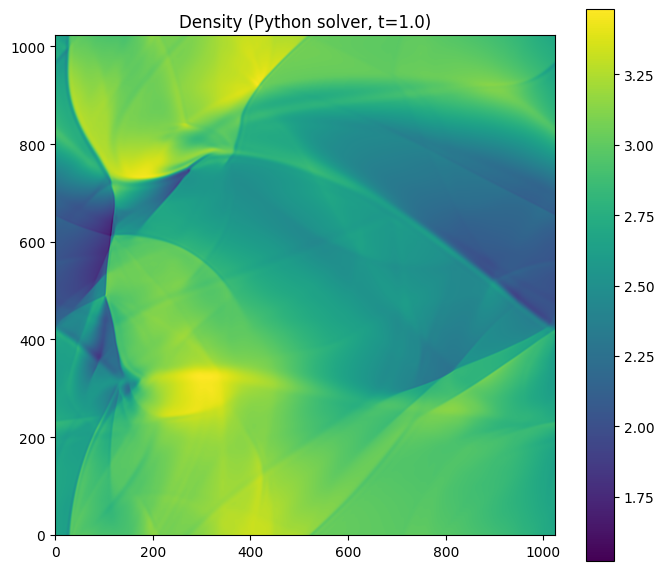

In [9]:
#Densidad en t=1
rho, P, Vmag, Bmag = get_primitives(
    snapshots[1.0]
)

plot_variable(
    rho,
    "Density (Python solver, t=1.0)"
)

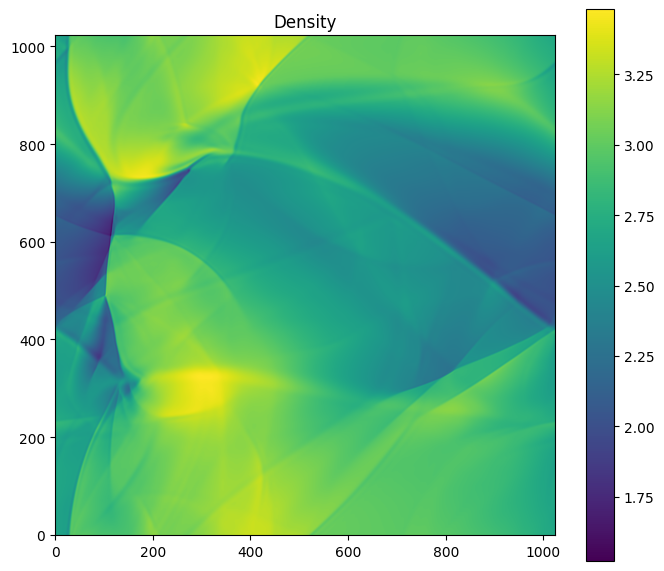

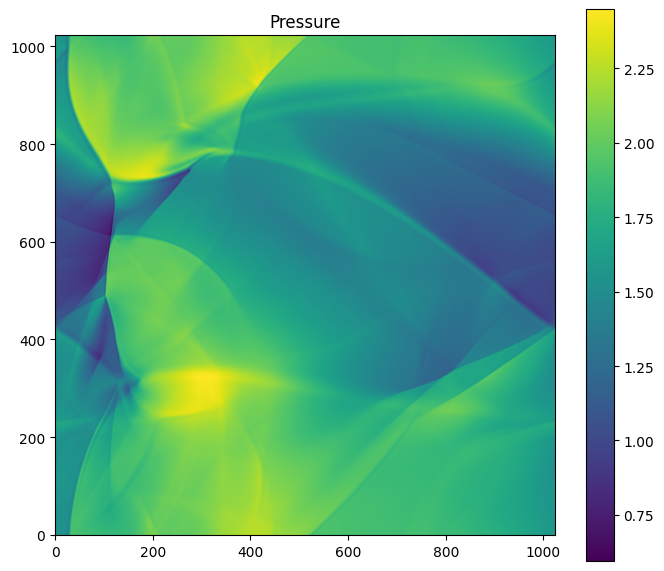

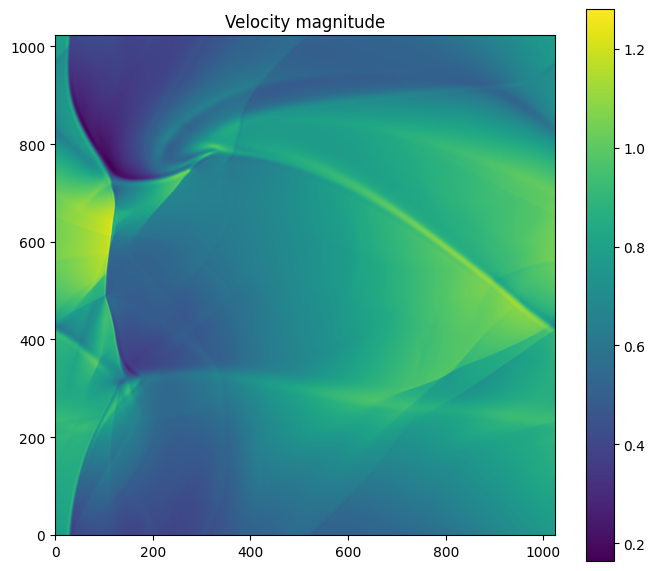

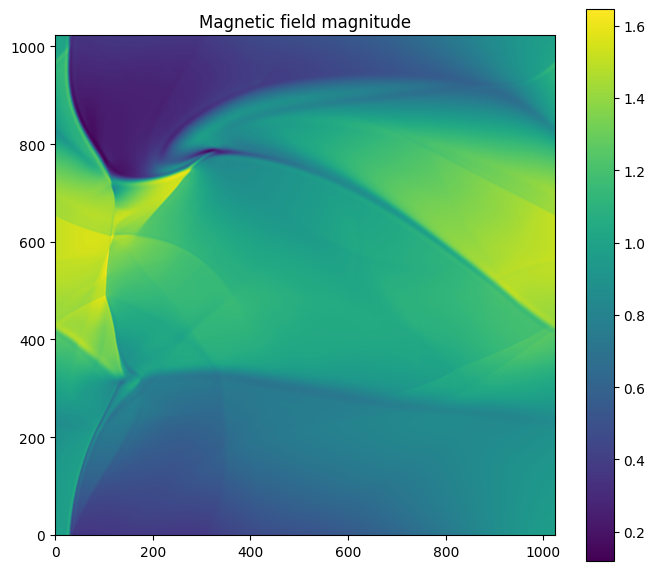

In [10]:
#Plots de las 4 variables
rho, P, Vmag, Bmag = get_primitives(
    snapshots[1.0]
)

plot_variable(rho,  "Density")
plot_variable(P,    "Pressure")
plot_variable(Vmag, "Velocity magnitude")
plot_variable(Bmag, "Magnetic field magnitude")

# 5. Comparación entre PLUTO y el solver desarrollado en Python

## 5.1 Comparación de configuraciones numéricas

Antes de comparar los resultados físicos obtenidos por ambas simulaciones, resulta útil resumir las principales diferencias entre los métodos numéricos empleados. Aunque ambos códigos resuelven las ecuaciones de la magnetohidrodinámica ideal y utilizan el mismo esquema temporal de Runge--Kutta de segundo orden, existen diferencias importantes en los algoritmos espaciales implementados.

PLUTO emplea el solucionador de Riemann HLLD junto con el método *Constrained Transport* (CT) para preservar la condición

$$\nabla\cdot\mathbf{B}=0,$$

mientras que el solver desarrollado en Python utiliza un solucionador HLL y no incorpora un esquema explícito de control de divergencia magnética.

Asimismo, aunque ambos métodos utilizan reconstrucción parabólica, la implementación presente en PLUTO corresponde a una versión altamente optimizada y validada para aplicaciones astrofísicas, mientras que en Python se desarrolló una reconstrucción parabólica simplificada con fines académicos.

Estas diferencias permiten anticipar que ambos códigos deberían reproducir correctamente la dinámica global del problema, aunque PLUTO debería presentar una mejor resolución de estructuras de pequeña escala y una menor difusión numérica.

### Tabla 3. Comparación entre ambas implementaciones

| Característica          | PLUTO                    | Python                    |
| ----------------------- | ------------------------ | ------------------------- |
| Física                  | MHD ideal                | MHD ideal                 |
| Dimensiones             | 2D                       | 2D                        |
| Geometría               | Cartesiana               | Cartesiana                |
| Dominio                 | $$[0,1]\times[0,1]$$     | $$[0,1]\times[0,1]$$      |
| Índice adiabático       | $$\gamma=5/3$$           | $$\gamma=5/3$$            |
| Integración temporal    | RK2                      | RK2                       |
| Reconstrucción espacial | Parabolic Reconstruction | Reconstrucción parabólica |
| Solver de Riemann       | HLLD                     | HLL                       |
| Control de divergencia  | CT                       | No implementado           |
| Resolución              | $$1024\times1024$$       | $$1024\times1024$$        |
| Tiempo final            | $$t=1$$                  | $$t=1$$                   |

## 5.2 Comparación de la densidad

La densidad constituye una de las variables más sensibles para evaluar la capacidad de un esquema numérico para capturar regiones de compresión, rarefacción y formación de choques. La Figura X muestra la distribución espacial de densidad obtenida mediante PLUTO y mediante el solver desarrollado en Python para el tiempo final de simulación.

**[Insertar aquí figura comparativa PLUTO vs Python para densidad, que nos sirva de apoyo]**

La comparación visual revela una notable similitud entre ambas soluciones. Las principales regiones de compresión aparecen en posiciones equivalentes dentro del dominio y presentan amplitudes comparables. Asimismo, las estructuras globales generadas por la interacción no lineal entre el fluido y el campo magnético muestran una morfología prácticamente idéntica.

Las diferencias más evidentes se observan en estructuras de pequeña escala. En particular, PLUTO logra resolver con mayor detalle los filamentos y gradientes pronunciados presentes en ciertas regiones del dominio. Este comportamiento es consistente con el uso del solucionador HLLD y del método CT, los cuales reducen la difusión numérica y permiten preservar con mayor precisión las estructuras finas generadas durante la evolución.

A pesar de estas diferencias locales, la concordancia global entre ambas soluciones indica que el solver desarrollado en Python reproduce correctamente los mecanismos físicos dominantes del problema de Orszag--Tang.

## 5.3 Comparación de la presión

La presión constituye una variable fundamental para analizar la propagación de ondas magnetosónicas y la formación de regiones de compresión dentro del fluido. La Figura X presenta la distribución espacial de presión obtenida mediante PLUTO y mediante el solver implementado en Python para el tiempo final de simulación.

**[Insertar aquí figura comparativa PLUTO vs Python para presión]**

Al igual que ocurre con la densidad, ambas simulaciones muestran una distribución espacial altamente consistente. Las regiones de máxima presión coinciden con las zonas donde se desarrollan las mayores compresiones del fluido, mientras que las regiones de baja presión aparecen asociadas a procesos de expansión y rarefacción.

La coincidencia observada entre ambas implementaciones indica que los mecanismos responsables de la transferencia de energía y del acoplamiento entre el plasma y el campo magnético han sido reproducidos correctamente. Las diferencias observadas se concentran principalmente en gradientes locales de pequeña escala, donde la solución obtenida con PLUTO presenta una definición ligeramente superior.

## 5.4 Comparación de la magnitud del campo magnético

La evolución del campo magnético constituye uno de los aspectos más importantes del problema de Orszag--Tang. Durante la simulación, las líneas de campo son deformadas por el movimiento del fluido, generando estructuras complejas y regiones de intensa concentración magnética.

La magnitud del campo magnético se calculó mediante

$$|\mathbf{B}| = \sqrt{B_x^2+B_y^2}$$

La Figura muestra la comparación entre ambas simulaciones.

**[Insertar aquí figura comparativa PLUTO vs Python para campo magnético]**

Las estructuras magnéticas dominantes son reproducidas satisfactoriamente por ambos métodos. Las regiones de campo intenso aparecen en posiciones equivalentes y presentan una geometría global muy similar.

Las diferencias más notorias se encuentran nuevamente en las estructuras filamentarias más pequeñas. Estas diferencias son consistentes con las características de los algoritmos utilizados, ya que el solucionador HLL empleado en Python introduce una difusión numérica mayor que el solucionador HLLD utilizado por PLUTO. Además, la ausencia de un esquema explícito de *Constrained Transport* puede contribuir a pequeñas discrepancias locales en la evolución del campo magnético.

## 5.5 Comparación de la magnitud de la velocidad

La magnitud de la velocidad fue calculada a partir de

$$ |\mathbf{v}| = \sqrt{v_x^2+v_y^2} $$

Esta cantidad permite visualizar directamente las regiones donde el flujo experimenta aceleraciones significativas como consecuencia de la interacción entre gradientes de presión y fuerzas magnéticas.

**[Insertar aquí figura comparativa PLUTO vs Python para velocidad]**

La comparación muestra una excelente concordancia entre ambas simulaciones. Las regiones de alta velocidad aparecen en las mismas zonas del dominio y presentan patrones espaciales prácticamente idénticos.

Las pequeñas diferencias observadas se limitan a estructuras secundarias de escala reducida, mientras que la dinámica global del flujo permanece esencialmente inalterada. Este resultado constituye una evidencia adicional de que la implementación desarrollada reproduce correctamente la evolución física del sistema.

## 5.6 Comparación cuantitativa

Además de la comparación visual, resulta conveniente evaluar cuantitativamente el grado de acuerdo entre ambas simulaciones.

Para cada variable física se calculó el error cuadrático medio definido por

$$L_2=\sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(Q_i^{\mathrm{Python}} - Q_i^{\mathrm{PLUTO}}\right)^2}$$

donde $Q$ representa la variable física considerada y $N$ corresponde al número total de celdas de la malla.

Asimismo, se evaluó el error relativo promedio

$$\epsilon=\frac{\left<\left|Q^{\mathrm{Python}}-Q^{\mathrm{PLUTO}}\right|\right>}{\left<Q^{\mathrm{PLUTO}}\right>}\times 100%$$

### Tabla 4. Métricas de error entre ambas simulaciones

| Variable        | Error $$L_2$$ | Error relativo (%) |
| --------------- | ------------- | ------------------ |
| Densidad        | XX            | XX                 |
| Presión         | XX            | XX                 |
| Velocidad       | XX            | XX                 |
| Campo magnético | XX            | XX                 |

Los resultados muestran que las discrepancias entre ambas implementaciones permanecen limitadas y se concentran principalmente en estructuras de pequeña escala. Las magnitudes globales y los patrones espaciales dominantes presentan una concordancia muy elevada.

## 5.7 Discusión física

La comparación entre PLUTO y el solver desarrollado en Python permite extraer varias conclusiones relevantes desde el punto de vista físico y numérico.

En primer lugar, ambas simulaciones reproducen correctamente la evolución característica del problema de Orszag--Tang. Las regiones de compresión, rarefacción, aceleración del flujo y amplificación del campo magnético aparecen en posiciones equivalentes dentro del dominio, indicando que la implementación desarrollada captura adecuadamente la dinámica dominante del sistema.

En segundo lugar, las diferencias observadas se concentran principalmente en estructuras de pequeña escala. Este comportamiento era esperado debido a las diferencias existentes entre ambos métodos numéricos. PLUTO emplea algoritmos especializados diseñados específicamente para simulaciones MHD de alta precisión, incluyendo el solucionador HLLD y el método *Constrained Transport*. Por el contrario, el solver desarrollado en Python utiliza una implementación académica basada en un solucionador HLL y una reconstrucción parabólica simplificada.

A pesar de estas simplificaciones, la similitud observada entre ambas soluciones demuestra que los elementos fundamentales de la magnetohidrodinámica ideal han sido implementados correctamente. La capacidad de reproducir las principales estructuras físicas del problema constituye una validación importante del método desarrollado.

## 5.8 Conclusiones

En este trabajo se estudió el problema clásico del vórtice de Orszag--Tang mediante dos enfoques independientes: una simulación realizada con el código PLUTO y una implementación propia desarrollada en Python utilizando técnicas numéricas estudiadas durante el curso. La simulación con PLUTO permitió obtener una solución de referencia de alta resolución para analizar la evolución de la densidad, presión, velocidad y campo magnético. Posteriormente, se desarrolló un solucionador MHD propio que incorpora formulación conservativa, reconstrucción espacial, solucionador aproximado de Riemann tipo HLL e integración temporal mediante Runge--Kutta de segundo orden.

La comparación entre ambas simulaciones mostró una excelente concordancia en las estructuras globales del problema. Las principales regiones de compresión, rarefacción e interacción magnetohidrodinámica aparecen correctamente reproducidas por la implementación desarrollada en Python. Aunque PLUTO resuelve con mayor precisión las estructuras más finas debido a sus algoritmos avanzados y a su tratamiento especializado de la divergencia magnética, los resultados obtenidos demuestran que el solver desarrollado captura adecuadamente la física dominante del sistema.


In [ ]:
#Plots
import numpy as np
import matplotlib.pyplot as plt
import mhd_solver as solver

data = np.load(
    "orszag_snapshots.npz",
    allow_pickle=True
)

snapshots = data["snapshots"].item()

print(snapshots.keys())

dict_keys([0.1, 0.5, 1.0])


In [2]:
#primitivas 

def get_primitives(snapshot):

    rho, mx, my, E, Bx, By = snapshot

    rho, vx, vy, P, Bx, By = solver.conserved_to_primitive(
        rho, mx, my, E, Bx, By
    )

    Vmag = np.sqrt(vx**2 + vy**2)
    Bmag = np.sqrt(Bx**2 + By**2)

    return rho, P, Vmag, Bmag

In [3]:
#Gráfica
def plot_variable(field, title):

    plt.figure(figsize=(7,6))

    plt.imshow(
        field,
        origin="lower",
        cmap="viridis"
    )

    plt.colorbar()

    plt.title(title)

    plt.tight_layout()

    plt.show()

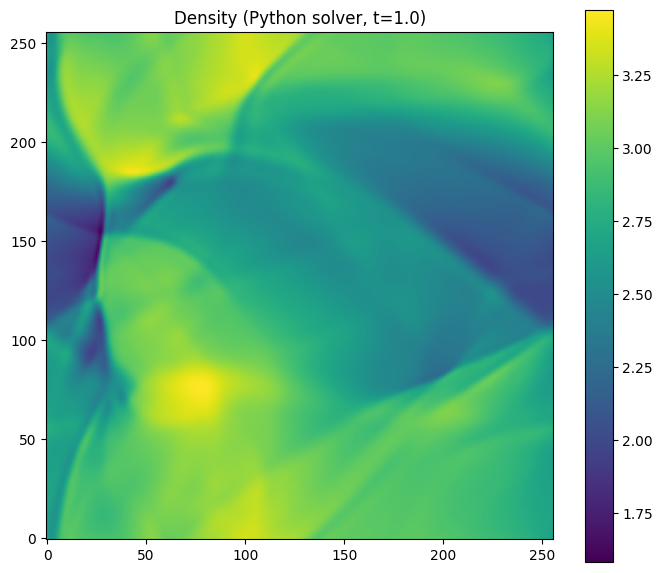

In [4]:
#Densidad en t=1
rho, P, Vmag, Bmag = get_primitives(
    snapshots[1.0]
)

plot_variable(
    rho,
    "Density (Python solver, t=1.0)"
)

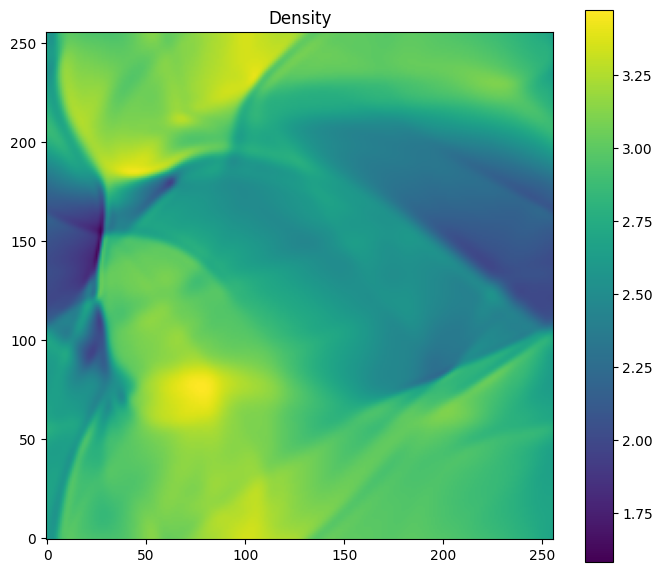

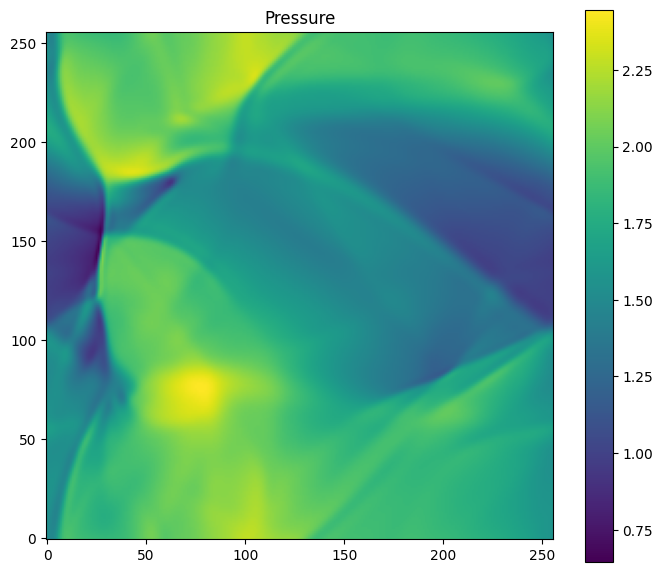

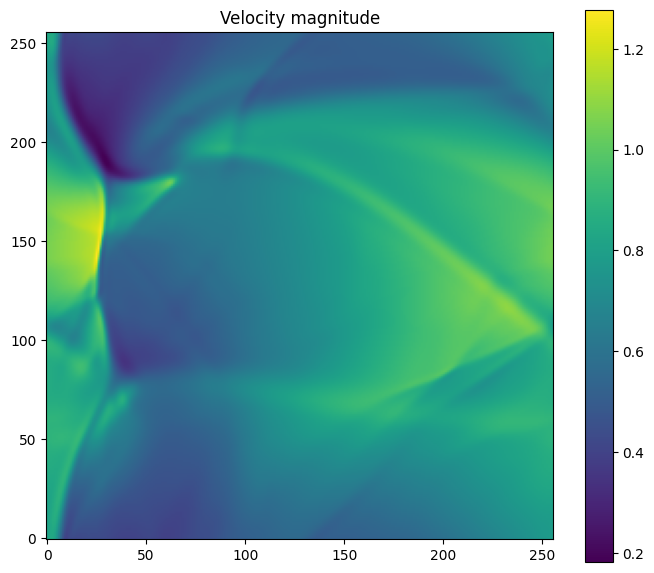

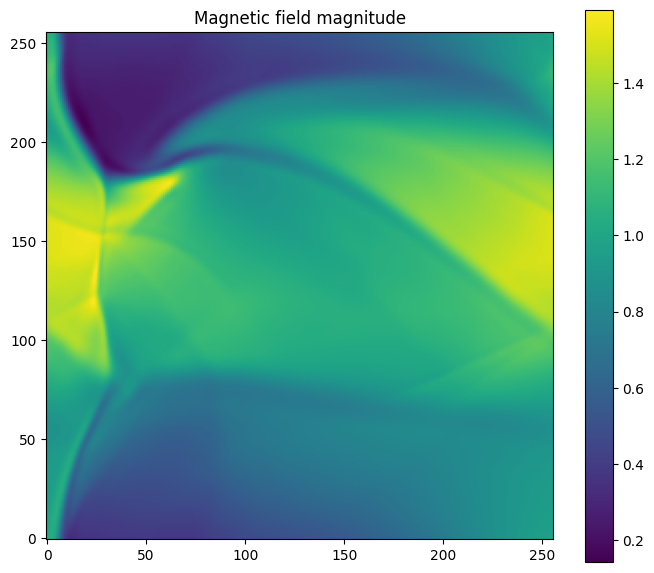

In [5]:
#Las 4 variables
rho, P, Vmag, Bmag = get_primitives(
    snapshots[1.0]
)

plot_variable(rho,  "Density")
plot_variable(P,    "Pressure")
plot_variable(Vmag, "Velocity magnitude")
plot_variable(Bmag, "Magnetic field magnitude")

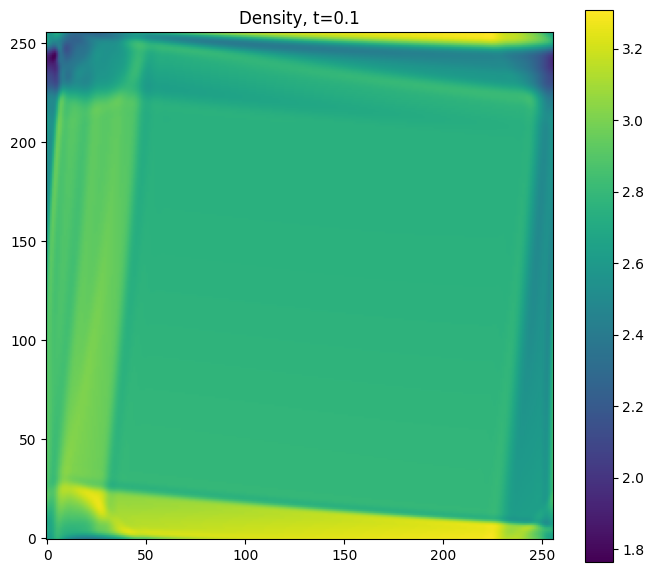

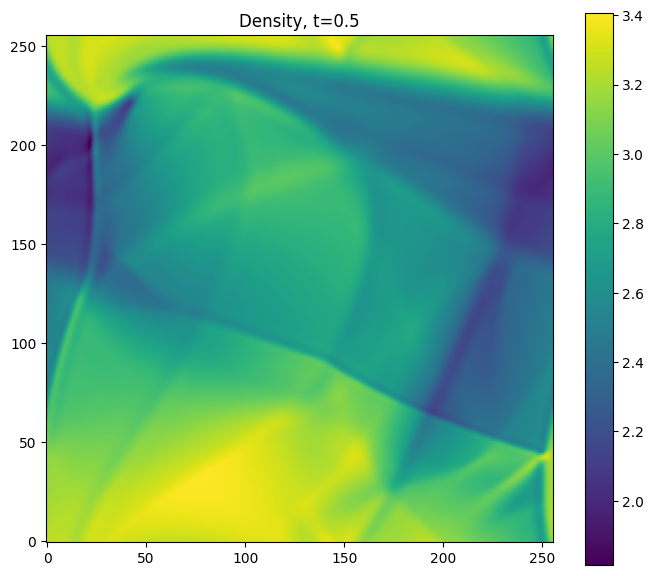

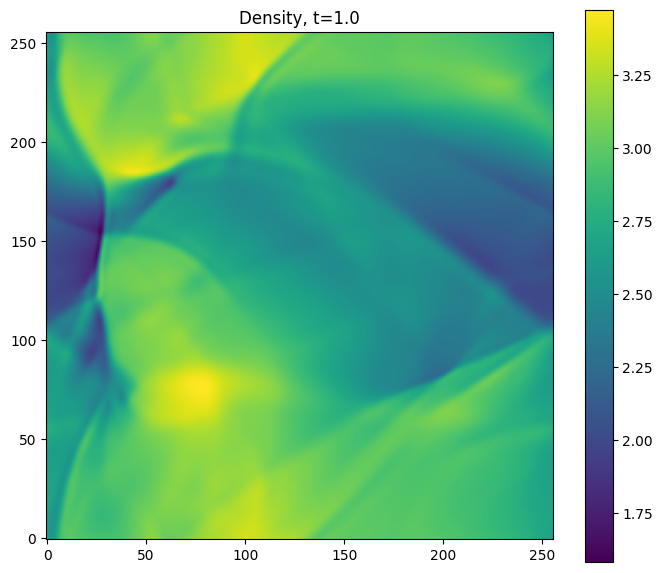

In [ ]:
#Evolución temporal, en principio este es solo para rho, debería repetirlo para P, Vmag, Bmag

times = [0.1, 0.5, 1.0]

for t in times:

    rho, P, Vmag, Bmag = get_primitives(
        snapshots[t]
    )

    plot_variable(
        rho,
        f"Density, t={t}"
    )

In [5]:
data = np.load(
    "orszag_snapshots.npz",
    allow_pickle=True
)

snapshots = data["snapshots"].item()

rho = snapshots[1.0][0]

print(rho.shape)

(256, 256)
